# Pipeline Validation & Sanity Check

This notebook steps through the Hydra pipeline to validate data loading, feature extraction, predictions, and loss computation.

In [1]:
import sys
import os
import torch
import matplotlib.pyplot as plt
from hydra import initialize, compose
from hydra.utils import instantiate

# Setup path
sys.path.append(os.path.abspath('../src'))

# Set PROJECT_ROOT for Hydra
os.environ['PROJECT_ROOT'] = os.path.abspath('..')


## 1. Initialize Hydra and Compose Config

In [2]:
with initialize(version_base='1.3', config_path='../configs'):
    cfg = compose(config_name='default', overrides=['+experiment=sanity_check'])
print(cfg.dataset)


{'_target_': 'muse_toolbox.data.BrudexDataModule', 'id': 'J3_BXLS_test', 'data_dir': '${paths.data_dir}', 'batch_size': 2, 'num_workers': 0, 'num_scenarios': [40, 20, 10], 'sampling_frequency': 8000, 'clean_speech_databases': ['Librispeech'], 'seed': 777, 'acc_device': 'cpu', 'reset': False, 'generation_config': {'_target_': 'muse_toolbox.data.ScenarioGenerationConfig', 'max_sources': 3, 'signal_lengths': 60.0, 'initial_noise_only_duration': [0.5, 5.0], 'snrs': [0, 5, 10, 15], 'source_power_range': 0.0, 'time_between_events': [0.5, 5.0], 'activations_only': True, 'remove_silence': True, 'neglect_silence4oracle_sa': 0.4, 'bridge_clean_speech_gaps': 0.1, 'vad_threshold2define_oracle': -60, 'vad_threshold2select_clean_speech': -30, 'fix_seglen': False}, 'brudex_config': {'_target_': 'muse_toolbox.data.BrudexConfig', 'reverb_conditions': ['low'], 'microphone_arrays': ['BTE_IE'], 'noise_types': [['babble', 'cafeteria'], ['babble', 'cafeteria'], ['babble', 'cafeteria']], 'doas': [[-150, -120

## 2. Instantiate DataModule and Fetch Batch

In [3]:
# Instantiate DataModule
datamodule = instantiate(cfg.dataset)
datamodule.setup('fit')
train_loader = datamodule.train_dataloader()

# Get a single batch
batch = next(iter(train_loader))
print(f'Batch size: {batch.batch_size}')
print(f'Audio length: {batch.raw_audio[0].shape}')


Batch size: 2
Audio length: torch.Size([6, 88000])


## 3. Visualize Raw Audio and Ground Truth SAD

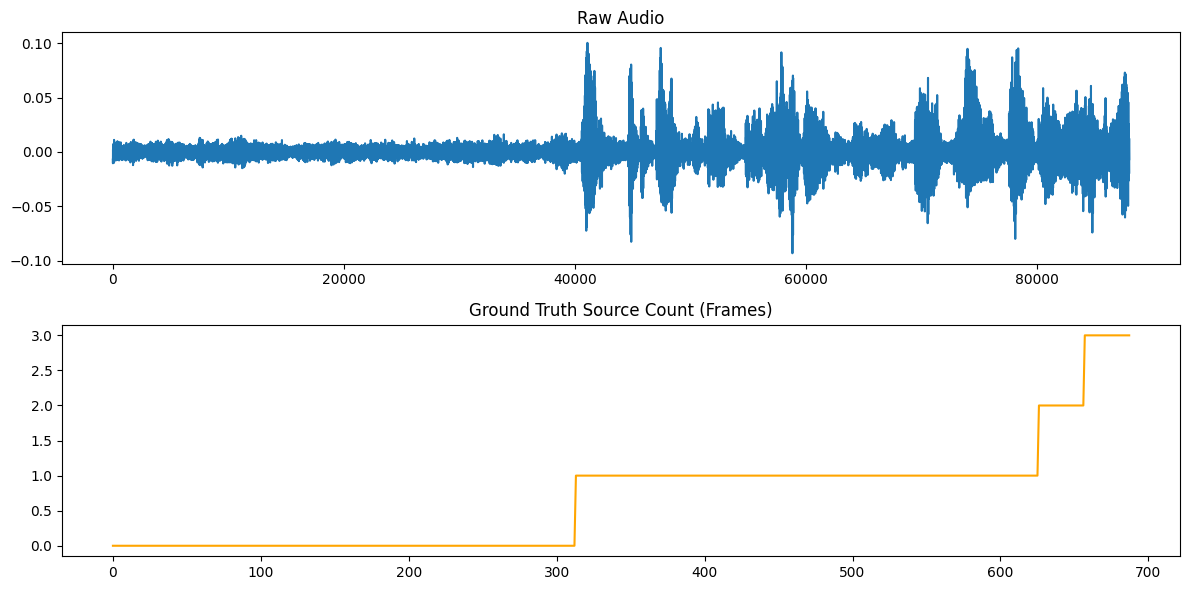

In [4]:
# Plotting audio and sad labels
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

audio = batch.raw_audio[0][0].numpy()  # First sample, first channel
axes[0].plot(audio)
axes[0].set_title('Raw Audio')

# Ground Truth Source Count
sad = batch.meta['source_count'][0].numpy()
axes[1].plot(sad, color='orange')
axes[1].set_title('Ground Truth Source Count (Frames)')

plt.tight_layout()
plt.show()


## 4. Feature Extraction (STFT)

/home/henrig/.local/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/henrig/.local/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias

Features shape: torch.Size([80, 688])


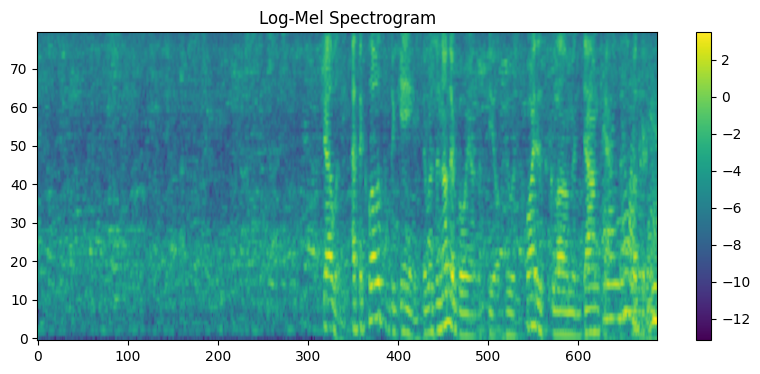

In [5]:
# Instantiate Model to get the transform
model = instantiate(cfg.model)

# Move batch to correct device
batch.to(model.device)

# Extract features
batch.apply_feature_extractor(model.feature_extractor)
print(f'Features shape: {batch.processed_features[0].shape}')

# Plot spectrogram
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(batch.processed_features[0].cpu().numpy(), aspect='auto', origin='lower')
ax.set_title('Log-Mel Spectrogram')
fig.colorbar(im, ax=ax)
plt.show()


## 5. Model Forward Pass & Predictions

Predictions shape: torch.Size([2, 688, 4])


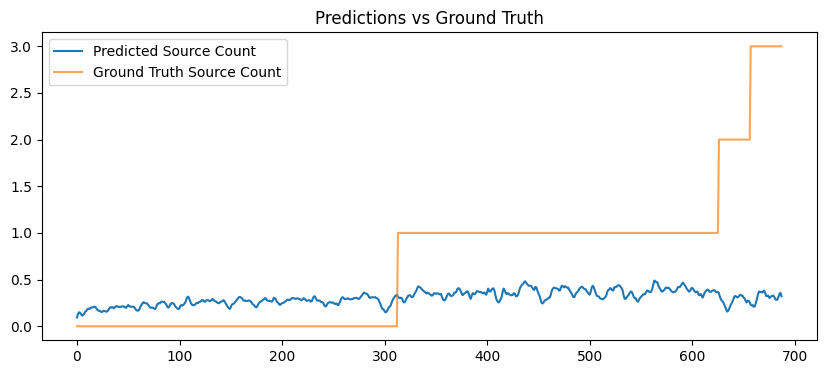

In [6]:
model.train()
with torch.no_grad():
    outputs = model(batch)

print('Predictions shape:', outputs.padded_estimates.shape)

# Plot predictions vs GT
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(outputs.padded_estimates[0, :, 0].cpu().numpy(), label='Predicted Source Count')
ax.plot(batch.meta['source_count'][0].numpy(), label='Ground Truth Source Count', alpha=0.7)
ax.legend()
plt.title('Predictions vs Ground Truth')
plt.show()


## 6. Loss Computation

In [7]:
# Fetch a fresh batch because the previous one was modified in-place and stripped of gradients
batch = next(iter(train_loader))
batch.to(model.device)

# Forward pass with gradients enabled
outputs = model(batch)
loss = outputs.compute_loss(model.criterion)['loss']
print(f'Computed Loss: {loss.item()}')

# Backward pass
loss.backward()

# Check gradients
has_grad = any(p.grad is not None for p in model.parameters())
print(f'Gradients propagated: {has_grad}')


Computed Loss: 1.418963074684143
Gradients propagated: True
